# 🖼️ Emotion Detection — Image Prediction

This notebook handles:
- Imports & configuration
- Model architecture (must match training)
- Loading saved model weights from `checkpoints/best_model.pth`
- Predicting emotion from a single image
- Visualising prediction with probability bar chart

**Prerequisites:** Run `train_model.ipynb` first so `checkpoints/best_model.pth` exists.

## 📦 Step 1 — Imports

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image

# ── Device setup ──────────────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


## ⚙️ Step 2 — Configuration

Must match the settings used during training.

In [2]:
class Config:
    """Configuration — must match train_model.ipynb exactly."""

    MODEL_NAME       = 'resnet18'
    NUM_CLASSES      = 7
    IMG_SIZE         = 224
    BEST_MODEL_PATH  = './checkpoints/best_model.pth'

    EMOTION_CLASSES = {
        0: 'Angry',
        1: 'Disgusted',
        2: 'Fearful',
        3: 'Happy',
        4: 'Neutral',
        5: 'Sad',
        6: 'Surprised'
    }


config = Config()
print("Configuration loaded!")
print(f"  Classes : {list(config.EMOTION_CLASSES.values())}")

Configuration loaded!
  Classes : ['Angry', 'Disgusted', 'Fearful', 'Happy', 'Neutral', 'Sad', 'Surprised']


## 🏗️ Step 3 — Model Architecture

Must be **identical** to the architecture used in training.

In [3]:
class EmotionDetectionModel(nn.Module):
    """
    ResNet18-based emotion detection model.
    Architecture must match train_model.ipynb exactly.
    """

    def __init__(self, model_name='resnet18', num_classes=7, pretrained=False):
        super(EmotionDetectionModel, self).__init__()

        if model_name == 'resnet18':
            self.backbone = models.resnet18(pretrained=pretrained)
            num_features  = self.backbone.fc.in_features

            # Same head as training
            self.backbone.fc = nn.Sequential(
                nn.Dropout(0.5),
                nn.Linear(num_features, num_classes)
            )
        else:
            raise ValueError(f"Model '{model_name}' not supported.")

    def forward(self, x):
        return self.backbone(x)


print("Model class defined!")

Model class defined!


## 💾 Step 4 — Load Saved Model

We load the **best checkpoint** saved during training (no retraining here).

In [4]:
# Create model (pretrained=False since we load our own weights)
model = EmotionDetectionModel(
    model_name=config.MODEL_NAME,
    num_classes=config.NUM_CLASSES,
    pretrained=False
).to(device)

# Check checkpoint exists
if not os.path.exists(config.BEST_MODEL_PATH):
    raise FileNotFoundError(
        f"Checkpoint not found at '{config.BEST_MODEL_PATH}'.\n"
        "Please run train_model.ipynb first!"
    )

# Load weights
model.load_state_dict(
    torch.load(config.BEST_MODEL_PATH, map_location=device)
)
model.eval()   # Switch to inference mode

print(f"✅ Model loaded from: {config.BEST_MODEL_PATH}")
print("Model is ready for prediction!")

✅ Model loaded from: ./checkpoints/best_model.pth
Model is ready for prediction!


## 🖼️ Step 5 — Image Transform

Uses the same normalisation as test_transform in training (no augmentation).

In [5]:
# Same as test_transform in train_model.ipynb
predict_transform = transforms.Compose([
    transforms.Resize((config.IMG_SIZE, config.IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

print("Prediction transform defined!")

Prediction transform defined!


## 🔮 Step 6 — Prediction Functions

In [6]:
def predict_emotion(image_path, model, device, transform, emotion_classes):
    """
    Predict the emotion for a single image file.

    Args:
        image_path    : Path to the image file (jpg, png, etc.)
        model         : Loaded EmotionDetectionModel
        device        : torch.device (cpu or cuda)
        transform     : torchvision transform pipeline
        emotion_classes: Dict {int: str} mapping index → emotion name

    Returns:
        emotion    (str)   : Predicted emotion label
        confidence (float) : Confidence score 0–1
        all_probs  (array) : Probability for each emotion class
    """
    model.eval()

    # ── Load and preprocess ───────────────────────────────────────────────────
    image        = Image.open(image_path).convert('RGB')   # Ensure 3-channel RGB
    image_tensor = transform(image).unsqueeze(0).to(device)  # [1, C, H, W]

    # ── Inference ─────────────────────────────────────────────────────────────
    with torch.no_grad():
        outputs    = model(image_tensor)
        probs      = torch.softmax(outputs, dim=1)         # Convert logits → probs
        confidence, predicted = torch.max(probs, 1)

    emotion    = emotion_classes[predicted.item()]
    confidence = confidence.item()
    all_probs  = probs.cpu().numpy()[0]

    return emotion, confidence, all_probs


def visualize_prediction(image_path, emotion, confidence, all_probs, emotion_classes):
    """
    Display the image alongside a horizontal probability bar chart.

    Args:
        image_path     : Path to the original image
        emotion        : Predicted emotion label
        confidence     : Confidence score
        all_probs      : Probability array for all classes
        emotion_classes: Dict {int: str}
    """
    image    = Image.open(image_path)
    emotions = list(emotion_classes.values())

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # ── Left panel: image with prediction ────────────────────────────────────
    axes[0].imshow(image)
    axes[0].set_title(
        f"Predicted: {emotion}\nConfidence: {confidence:.2%}",
        fontsize=14, fontweight='bold'
    )
    axes[0].axis('off')

    # ── Right panel: probability bars ─────────────────────────────────────────
    colors = ['#2ecc71' if e == emotion else '#95a5a6' for e in emotions]
    bars   = axes[1].barh(emotions, all_probs, color=colors, alpha=0.85, edgecolor='white')

    # Add probability labels to the right of each bar
    for bar, prob in zip(bars, all_probs):
        axes[1].text(
            prob + 0.01, bar.get_y() + bar.get_height() / 2,
            f'{prob:.3f}', va='center', fontsize=10
        )

    axes[1].set_xlabel('Probability', fontsize=12)
    axes[1].set_title('Emotion Probabilities', fontsize=14, fontweight='bold')
    axes[1].set_xlim([0, 1.15])
    axes[1].grid(axis='x', alpha=0.3)

    # Legend
    legend_patches = [
        mpatches.Patch(color='#2ecc71', label='Predicted'),
        mpatches.Patch(color='#95a5a6', label='Other')
    ]
    axes[1].legend(handles=legend_patches, loc='lower right')

    plt.tight_layout()
    plt.show()


print("Prediction functions defined!")

Prediction functions defined!


## 🧪 Step 7 — Test on Images

Edit the `test_images` list to point to your own image files.


Image     : ./test/happy/PrivateTest_2911075.jpg
Emotion   : Surprised
Confidence: 53.23%


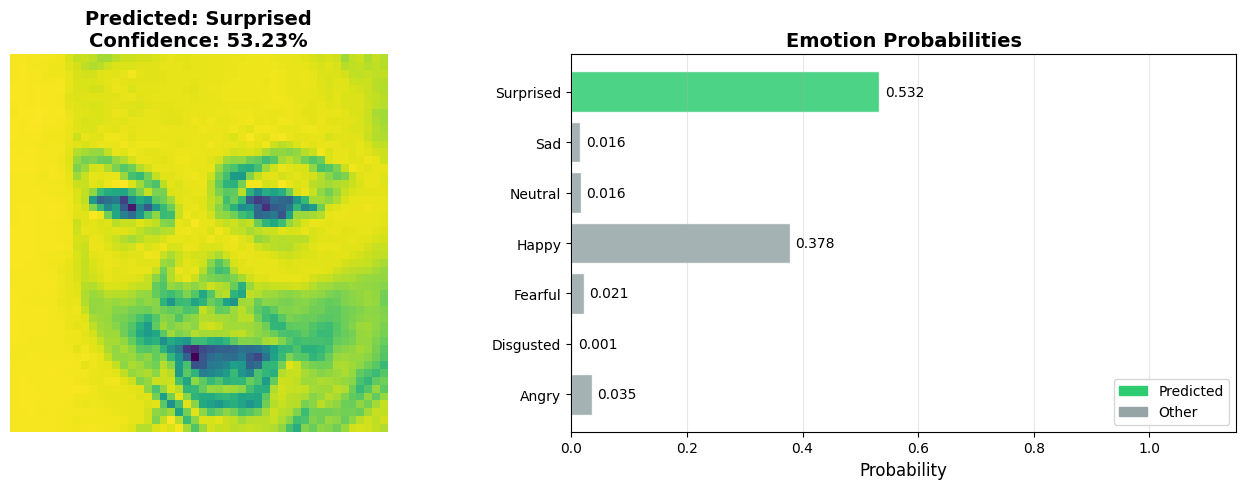


Image     : ./test/angry/PrivateTest_1488292.jpg
Emotion   : Angry
Confidence: 51.26%


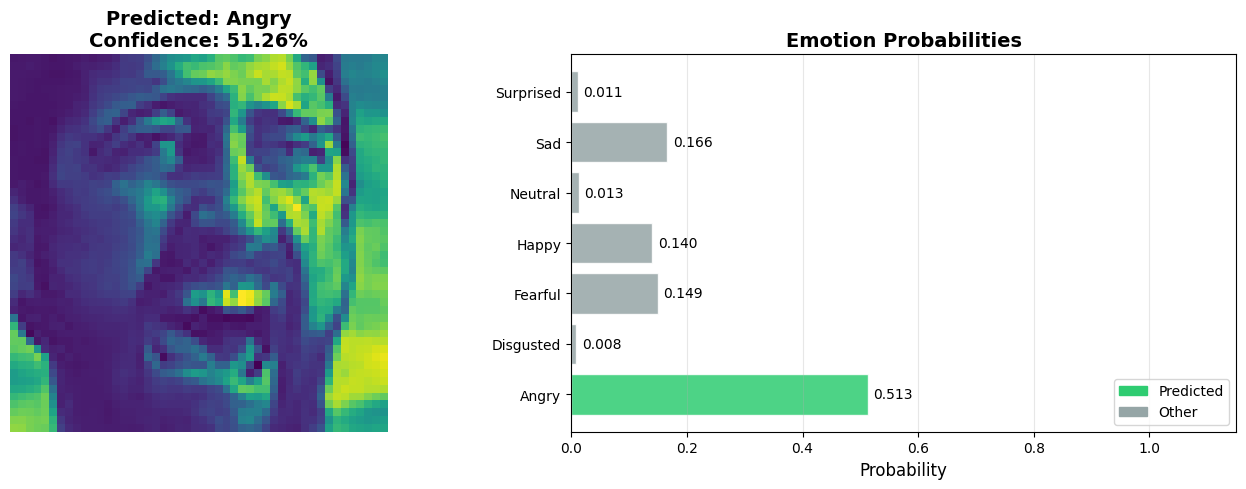


Image     : ./test/surprise/PrivateTest_914251.jpg
Emotion   : Surprised
Confidence: 77.04%


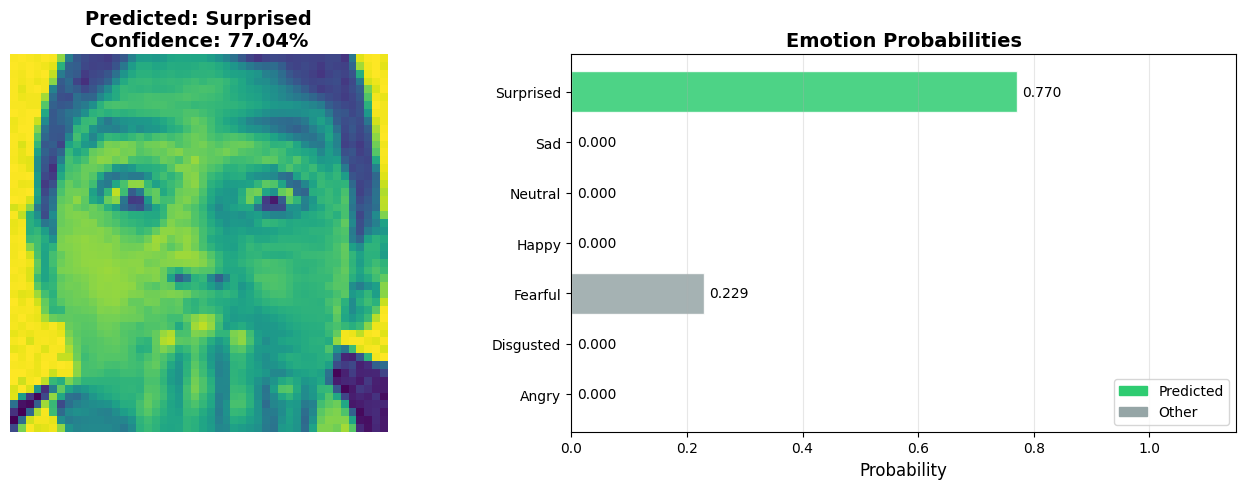


Image     : ./sample.jpg
Emotion   : Sad
Confidence: 50.89%


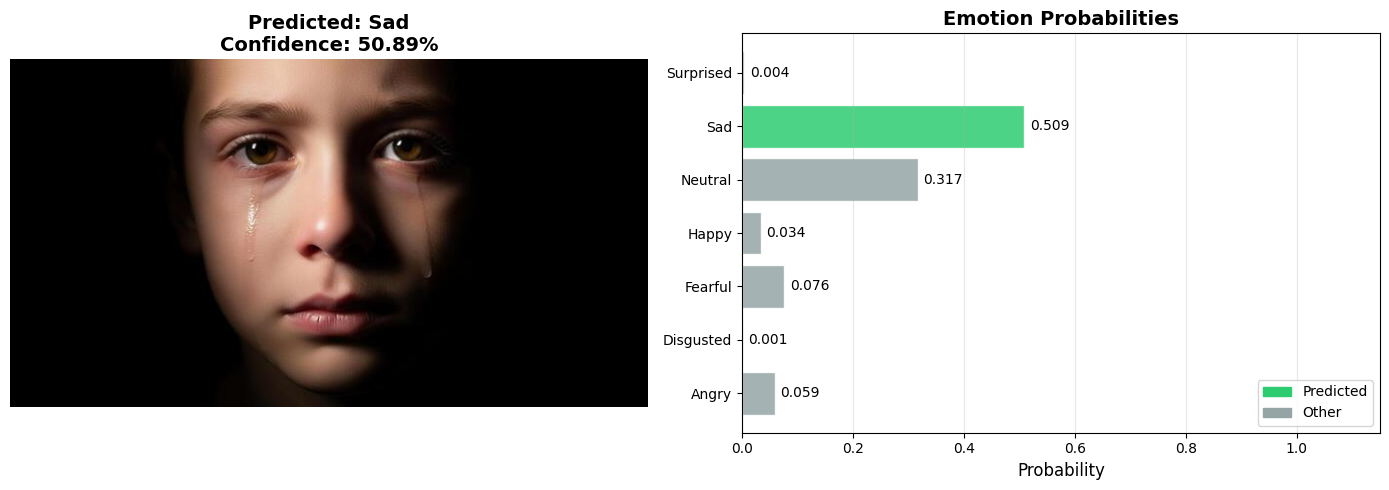


Image     : ./piyush.jpeg
Emotion   : Surprised
Confidence: 22.66%


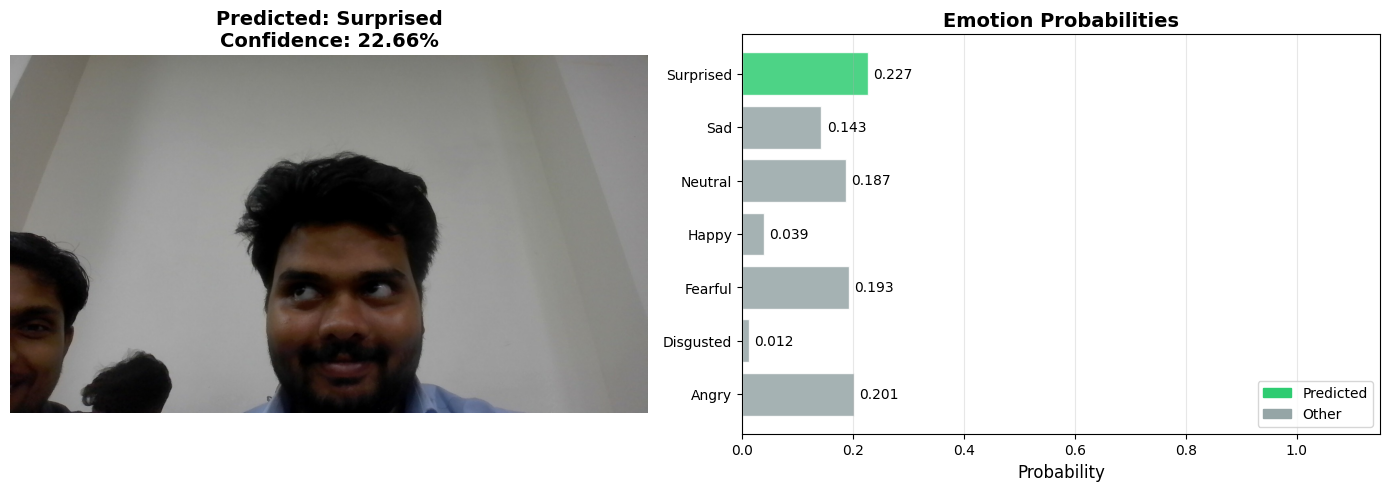

In [7]:
# ──────────────────────────────────────────────────────────────────────────────
# CHANGE THESE PATHS to point to your test images
# ──────────────────────────────────────────────────────────────────────────────
test_images = [
    './test/happy/PrivateTest_2911075.jpg',
    './test/angry/PrivateTest_1488292.jpg',
    './test/surprise/PrivateTest_914251.jpg',
    './sample.jpg',
    './piyush.jpeg',
]

# ── Run predictions ───────────────────────────────────────────────────────────
for image_path in test_images:

    if not os.path.exists(image_path):
        print(f"⚠️  Image not found: {image_path} — skipping.")
        continue

    emotion, confidence, all_probs = predict_emotion(
        image_path,
        model,
        device,
        predict_transform,
        config.EMOTION_CLASSES
    )

    print(f"\nImage     : {image_path}")
    print(f"Emotion   : {emotion}")
    print(f"Confidence: {confidence:.2%}")

    visualize_prediction(
        image_path,
        emotion,
        confidence,
        all_probs,
        config.EMOTION_CLASSES
    )